<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

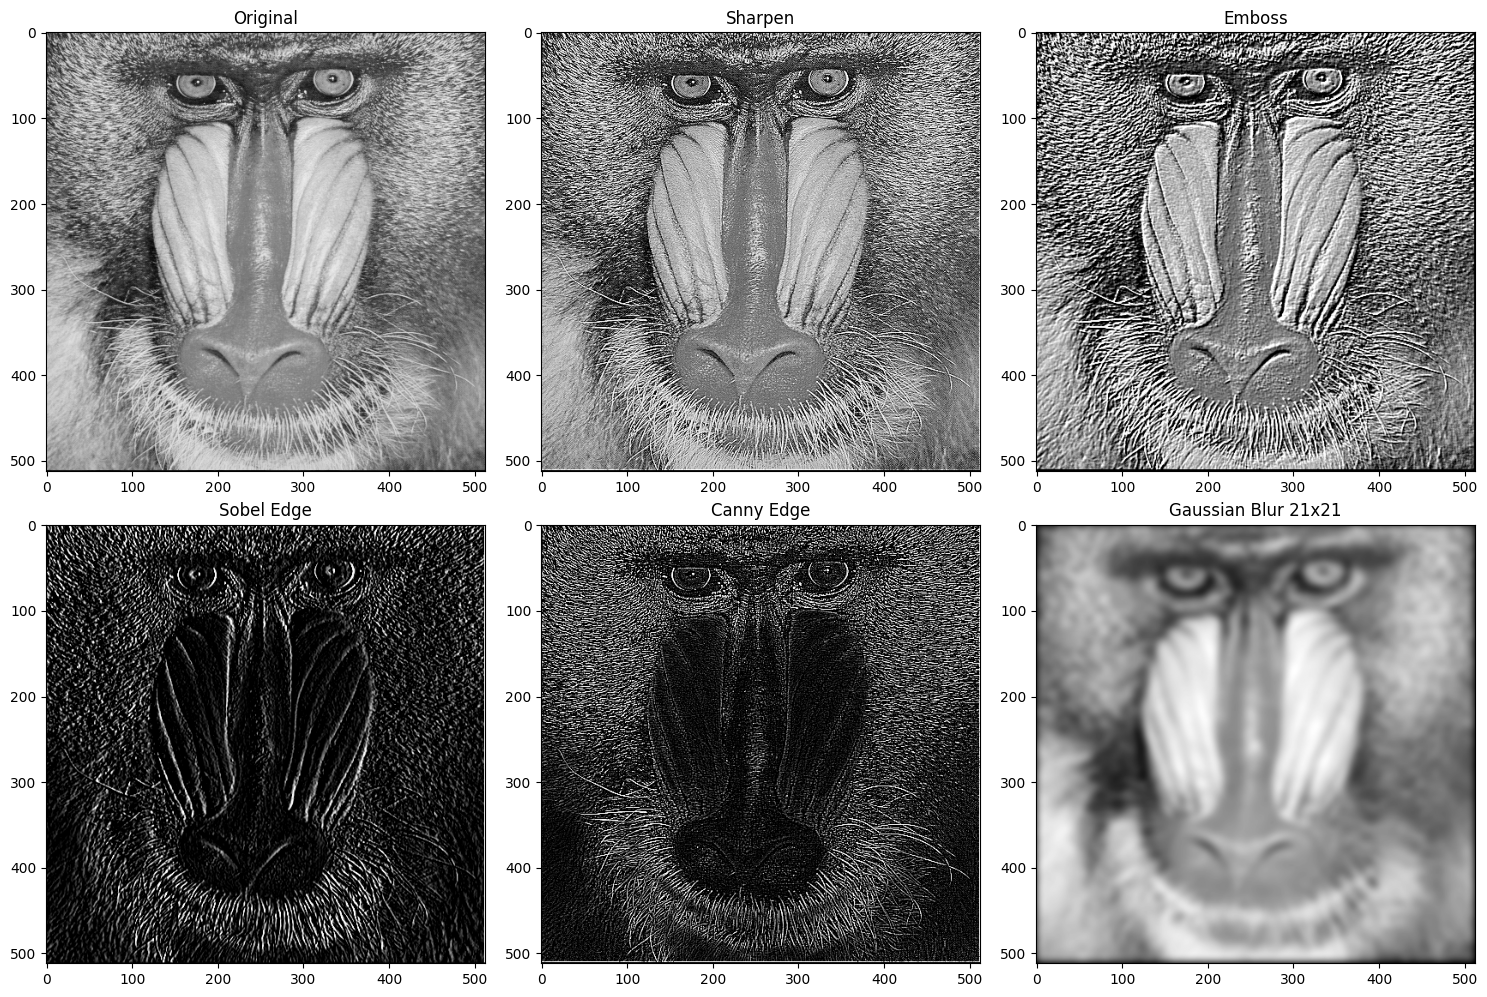

In [12]:
def convolution2d(image, kernel, stride, padding):
    h, w = image.shape
    kh, kw = kernel.shape

    padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    output_h = (h - kh + 2*padding) // stride + 1
    output_w = (w - kw + 2*padding) // stride + 1

    output = np.zeros((output_h, output_w), dtype=np.float32)

    for y in range(output_h):
        for x in range(output_w):
            region = padded[y*stride:y*stride+kh, x*stride:x*stride+kw]
            output[y, x] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

img = cv.imread('/content/gdrive/MyDrive/PCVK/mandrill.tiff', cv.IMREAD_GRAYSCALE)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gk = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gk @ gk.T

kernels = {
    "Sharpen": np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),

    "Emboss": np.array([[-2, -1, 0],
                        [-1,  1, 1],
                        [ 0,  1, 2]]),

    "Sobel Edge": np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]]),

    "Canny Edge": np.array([[-1, -1, -1],
                            [-1,  8, -1],
                            [-1, -1, -1]]),

    "Gaussian Blur 21x21": gaussian_kernel
}

results = {}
for name, kernel in kernels.items():
    pad = kernel.shape[0] // 2
    results[name] = convolution2d(img, kernel, stride=1, padding=pad)

plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

for i, (name, result) in enumerate(results.items(), 2):
    plt.subplot(2,3,i)
    plt.imshow(result, cmap='gray')
    plt.title(name)

plt.tight_layout()
plt.show()